In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna

from neuralforecast import NeuralForecast
import sys
import os
sys.path.append(os.path.abspath("../../"))
from QNeuralForecast.dlinear import QDLinear
from QNeuralForecast.patchtst import QPatchTST
from QNeuralForecast.timesnet import QTimesNet
from QNeuralForecast.nhits import QNHITS
from neuralforecast.models import DLinear, NHITS, PatchTST, TimesNet

from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.tensorboard import SummaryWriter
from neuralforecast.losses.numpy import mae, mse, rmse, mape, smape, mase

In [ ]:
df = pd.read_csv("../data/train_prepared.csv", parse_dates=["Date"], low_memory=False)
df = df.sort_values(["Store","Date"])

split_date = "2015-01-01"
train_df = df[df["Date"] < split_date].copy()
test_df  = df[df["Date"] >= split_date].copy()

In [ ]:
HORIZON = 100
model_classes = [DLinear, QDLinear]
#models_classes = [DLinear, QDLinear, NHITS, QNHITS, PatchTST, QPatchTST, TimesNet, QTimesNet]

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
# --- Hyperparameter search space ---
HYPERPARAM_GRID = {
    "input_size":    [100, 200, 400],
    "max_steps":     [50, 100, 300],
    "learning_rate": (1e-4, 1e-1),   # log-uniform range
    "scaler_type":   ["standard", "robust", "minmax", "identity"],
}

def objective(trial):
    input_size = trial.suggest_categorical("input_size", HYPERPARAM_GRID["input_size"])
    max_steps = trial.suggest_categorical("max_steps", HYPERPARAM_GRID["max_steps"])
    learning_rate = trial.suggest_float("learning_rate", *HYPERPARAM_GRID["learning_rate"], log=True)
    scaler_type = trial.suggest_categorical("scaler_type", HYPERPARAM_GRID["scaler_type"])

    trial_models = [
        cls(
            h=HORIZON,
            input_size=input_size,
            max_steps=max_steps,
            learning_rate=learning_rate,
            scaler_type=scaler_type,
            start_padding_enabled=True,
        )
        for cls in model_classes
    ]

    nf_trial = NeuralForecast(models=trial_models, freq="D")
    cv = nf_trial.cross_validation(
        train_df, n_windows=4, step_size=100,
        verbose=False, refit=False,
        id_col="Store", time_col="Date", target_col="Sales"
    )

    model_cols = [c for c in cv.columns if c not in ["Store", "Date", "Sales", "cutoff"]]
    # Minimise average MAE across all models and folds
    avg_mae = float(np.mean([mae(cv["Sales"].values, cv[m].values) for m in model_cols]))
    return avg_mae

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="rossmann_hpo",
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

best_params = study.best_params
print(f"\nBest CV MAE : {study.best_value:.4f}")
print(f"Best params : {best_params}")

In [ ]:
# Build final models using the best hyperparameters found by Optuna
models = [
    cls(
        h=HORIZON,
        input_size=best_params["input_size"],
        max_steps=best_params["max_steps"],
        learning_rate=best_params["learning_rate"],
        scaler_type=best_params["scaler_type"],
        start_padding_enabled=True,
        **{"logger": TensorBoardLogger("lightning_logs", name=cls.__name__, prefix="final_")},
    )
    for cls in model_classes
]

nf = NeuralForecast(models=models, freq="D")

Best CV MAE : 1629.0756
Best params : {'input_size': 100, 'max_steps': 50, 'learning_rate': 0.0005117322495832655, 'scaler_type': 'robust'}

 number       value  params_input_size  params_max_steps  params_learning_rate params_scaler_type
     17 1629.075598                100                50              0.000512             robust
     18 1641.040286                100                50              0.000473           standard
     19 1645.530944                100                50              0.000360           standard
     15 1680.675514                100               100              0.000784             robust
      4 1686.072579                200                50              0.000861             robust
      3 1686.166260                100               100              0.000820             robust
     16 1691.314286                200               100              0.000108             robust
      1 1700.740156                200                50              0.000

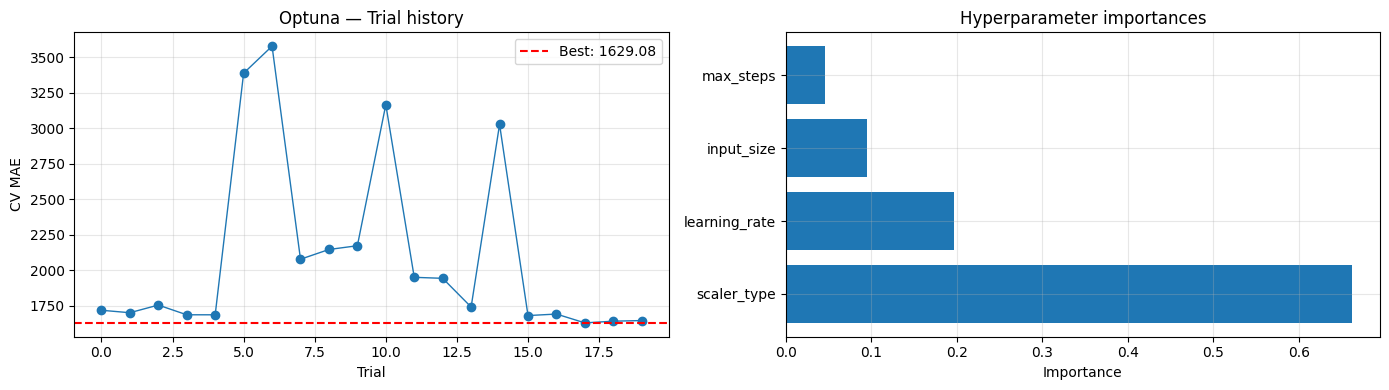

In [ ]:
# --- HPO results summary ---
print(f"Best CV MAE : {study.best_value:.4f}")
print(f"Best params : {study.best_params}\n")

trials_df = study.trials_dataframe().sort_values("value")
print(trials_df[["number", "value", "params_input_size", "params_max_steps",
                  "params_learning_rate", "params_scaler_type"]].to_string(index=False))

# Plot trial history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot([t.number for t in study.trials],
             [t.value for t in study.trials], marker='o', linewidth=1)
axes[0].axhline(study.best_value, color='red', linestyle='--', label=f"Best: {study.best_value:.2f}")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV MAE")
axes[0].set_title("Optuna — Trial history")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()))
axes[1].set_xlabel("Importance")
axes[1].set_title("Hyperparameter importances")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# HPO already selected the best hyperparams via CV — fit directly on the full training set.
nf.fit(train_df, id_col="Store", time_col="Date", target_col="Sales")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Forecast date range: 2014-07-01 00:00:00 → 2015-04-10 00:00:00
Test    date range:  2015-01-01 00:00:00 → 2015-07-31 00:00:00
Matched rows after merge: 77738
Models found: ['DLinear', 'QDLinear']
  [DLinear] test metrics logged to TensorBoard.
  [QDLinear] test metrics logged to TensorBoard.

Test-set metrics per model:
  QDLinear: MAE=1450.9671  MSE=3717486.6376  RMSE=1928.0785  MAPE=0.2362  MASE=0.6105
  DLinear: MAE=1592.8685  MSE=4523609.9948  RMSE=2126.8780  MAPE=0.2527  MASE=0.6702

Top 5 Stores (best predicted on average): [794, 789, 558, 656, 958]


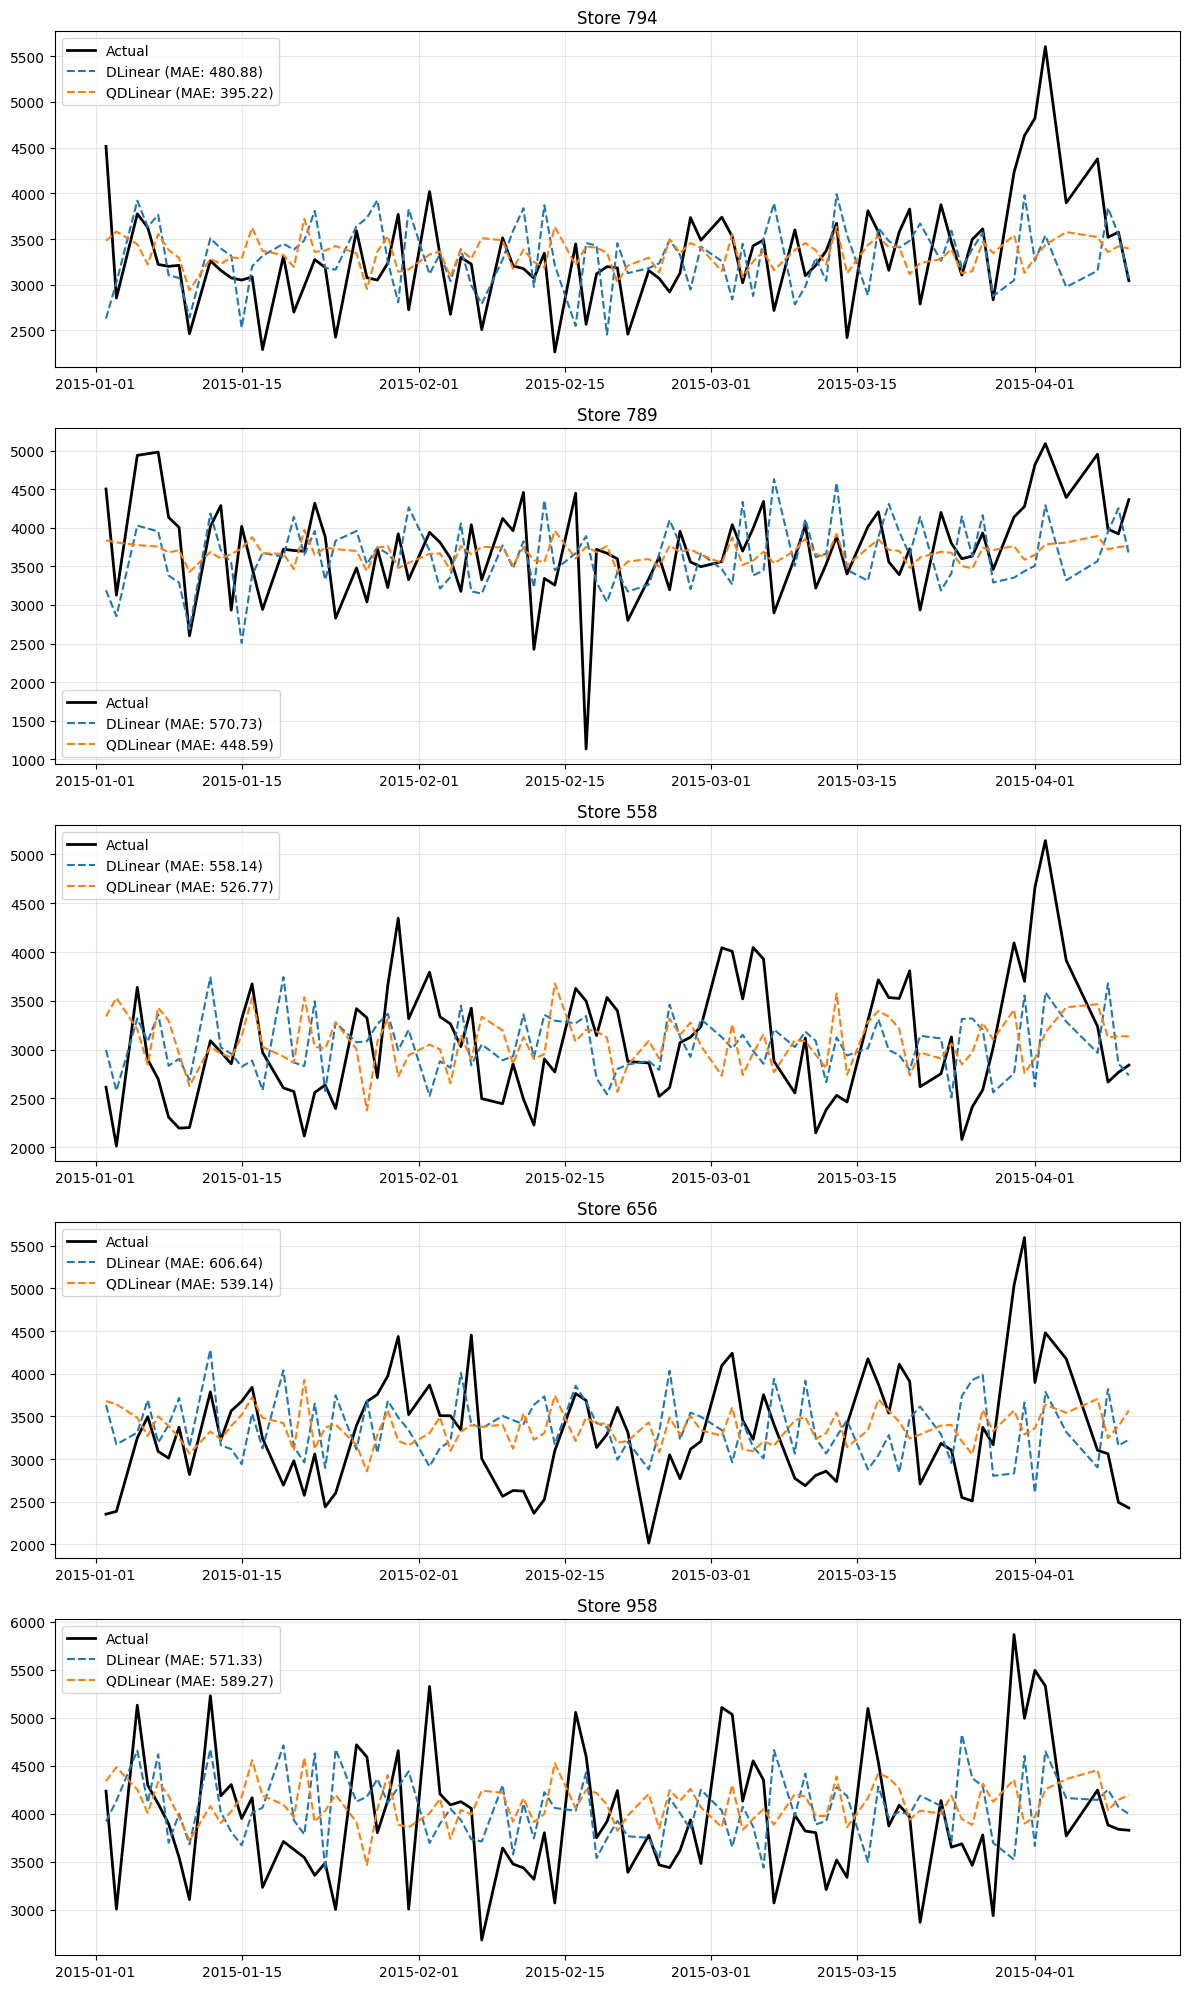

In [ ]:
# --- Final test-set evaluation ---
# nf.fit() was called on the full train_df, so predict() starts from 2015-01-01.
forecasts = nf.predict().reset_index()
print("Forecast date range:", forecasts["Date"].min(), "→", forecasts["Date"].max())
print("Test    date range: ", test_df["Date"].min(),  "→", test_df["Date"].max())

comparison = test_df[["Store", "Date", "Sales"]].merge(forecasts, on=["Store", "Date"], how="inner")
print(f"Matched rows after merge: {len(comparison)}")

model_names = [col for col in forecasts.columns if col not in ["index", "Store", "Date"]]
print(f"Models found: {model_names}")

# y_train for MASE baseline (weekly seasonality for daily data)
y_train_global = train_df["Sales"].values
SEASONALITY = 7

# Calculate metrics and log to TensorBoard
results = {}
for model in model_names:
    model_MAE  = mae( comparison["Sales"], comparison[model])
    model_MSE  = mse( comparison["Sales"], comparison[model])
    model_RMSE = rmse(comparison["Sales"], comparison[model])
    model_MAPE = mape(comparison["Sales"], comparison[model])
    model_MASE = mase(comparison["Sales"], comparison[model],
                      y_train=y_train_global, seasonality=SEASONALITY)
    results[model] = {"MAE": model_MAE, "MSE": model_MSE,
                      "RMSE": model_RMSE, "MAPE": model_MAPE, "MASE": model_MASE}

    writer = SummaryWriter(log_dir=f"lightning_logs/{model}/test_metrics")
    for metric_name, val in results[model].items():
        writer.add_scalar(f"test/{metric_name}", val, 0)
    writer.close()
    print(f"  [{model}] test metrics logged to TensorBoard.")

print("\nTest-set metrics per model:")
for m, scores in sorted(results.items(), key=lambda x: x[1]["MAE"]):
    print(f"  {m}: MAE={scores['MAE']:.4f}  MSE={scores['MSE']:.4f}  "
          f"RMSE={scores['RMSE']:.4f}  MAPE={scores['MAPE']:.4f}  MASE={scores['MASE']:.4f}")

# Top 5 best-predicted stores
comparison["avg_model_error"] = sum(
    (comparison["Sales"] - comparison[m]).abs() for m in model_names
) / len(model_names)

top_5_stores = (comparison.groupby("Store")["avg_model_error"]
                           .mean().sort_values().head(5).index.tolist())
print(f"\nTop 5 Stores (best predicted on average): {top_5_stores}")

# Plot
fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=False)
for i, store_id in enumerate(top_5_stores):
    store_data = comparison[comparison["Store"] == store_id]
    ax = axes[i]
    ax.plot(store_data["Date"], store_data["Sales"], label="Actual", color='black', linewidth=2)
    for model in model_names:
        store_mae = (store_data["Sales"] - store_data[model]).abs().mean()
        ax.plot(store_data["Date"], store_data[model],
                label=f"{model} (MAE: {store_mae:.2f})", linestyle='--')
    ax.set_title(f"Store {store_id}")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()